In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as pt
import plotly.express as px
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Upload the CSV file from your local machine into the Colab environment.
# A file picker dialog will appear — select weatherAUS.csv.
# This step is specific to Google Colab; skip it if running locally.
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [3]:
input_df=pd.read_csv('data.csv')
input_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [4]:
input_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
input_df = input_df.drop(columns=['id', 'Unnamed: 32'])
input_df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [6]:
input_df.isnull().sum()
# Total missing values in each column
# Every column will show 0 — clean dataset, nothing missing

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [7]:
input_df.isnull().sum().sum()
#indicates Total missing values in the entire DataFrame (single number)

np.int64(0)

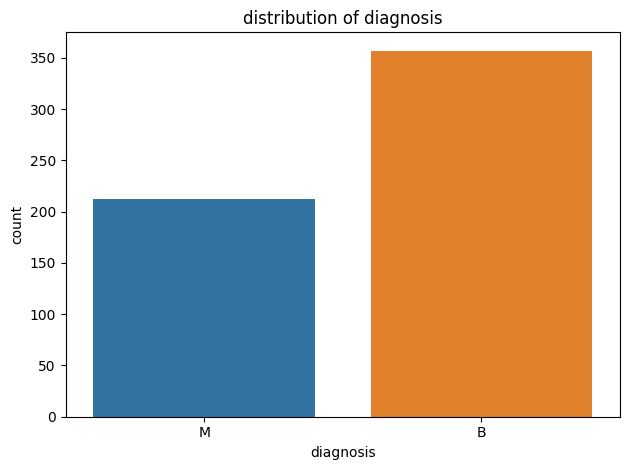

In [ ]:
sns.countplot(data=input_df,x='diagnosis',hue='diagnosis')
pt.title('distribution of diagnosis')
pt.xlabel('diagnosis')
pt.ylabel('count')
pt.tight_layout()
pt.show()

In [ ]:
print(input_df['diagnosis'].value_counts)


<bound method IndexOpsMixin.value_counts of 0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: diagnosis, Length: 569, dtype: object>


In [ ]:
print(input_df['diagnosis'].value_counts(normalize=True) * 100)

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [8]:
input_df['diagnosis_code'] = input_df['diagnosis'].map({'M': 1, 'B': 0})

In [9]:
numeric_df  = input_df.drop(columns=['diagnosis'])
target_corr = numeric_df.corr()['diagnosis_code'].drop('diagnosis_code')
target_corr = target_corr.sort_values(ascending=False)

print(target_corr)

concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0.006522
texture_se                -0

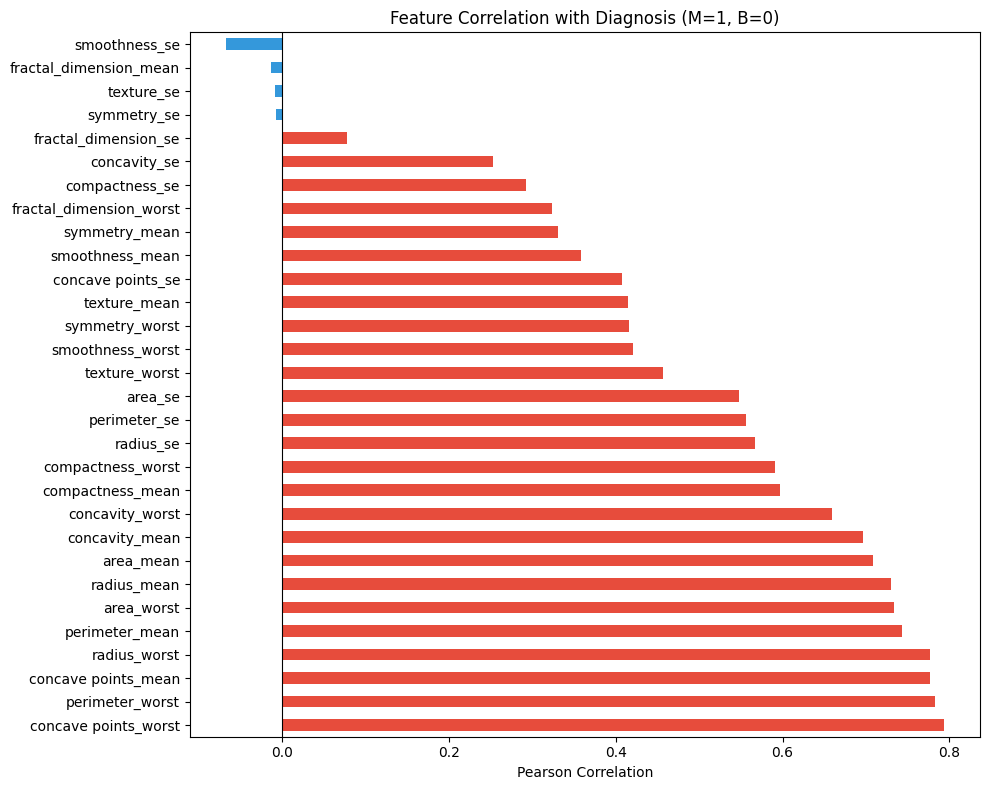

In [ ]:
# Visualise as a bar chart — much easier to read than numbers
pt.figure(figsize=(10, 8))
target_corr.plot(kind='barh', color=target_corr.map(lambda x: '#e74c3c' if x > 0 else '#3498db'))
pt.title('Feature Correlation with Diagnosis (M=1, B=0)')
pt.xlabel('Pearson Correlation')
pt.axvline(x=0, color='black', linewidth=0.8)
pt.tight_layout()
pt.show()

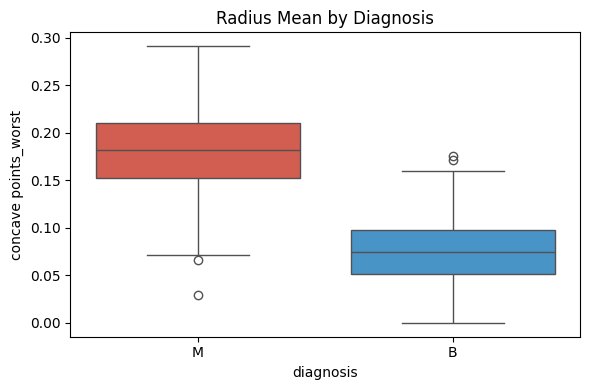

In [ ]:
# Pick any feature — replace 'concave points_worst' with whatever you want to explore
pt.figure(figsize=(6, 4))
sns.boxplot(x='diagnosis', y='concave points_worst', data=input_df,
            hue='diagnosis', palette={'M': '#e74c3c', 'B': '#3498db'}, legend=False)
pt.title('Radius Mean by Diagnosis')
pt.tight_layout()
pt.show()

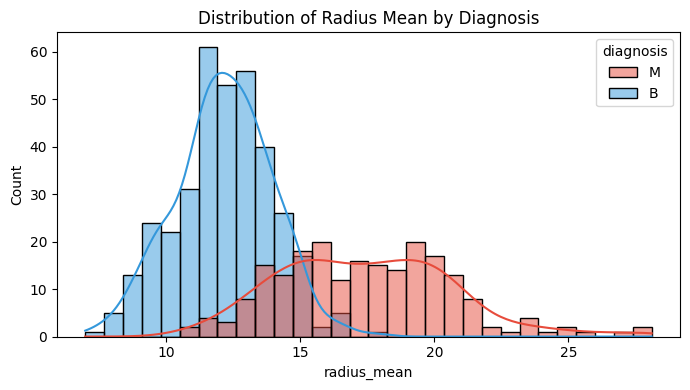

In [ ]:
pt.figure(figsize=(7, 4))
sns.histplot(data=input_df, x='radius_mean', hue='diagnosis',
             palette={'M': '#e74c3c', 'B': '#3498db'},
             kde=True,          # adds a smooth curve over the histogram
             bins=30)
pt.title('Distribution of Radius Mean by Diagnosis')
pt.tight_layout()
pt.show()

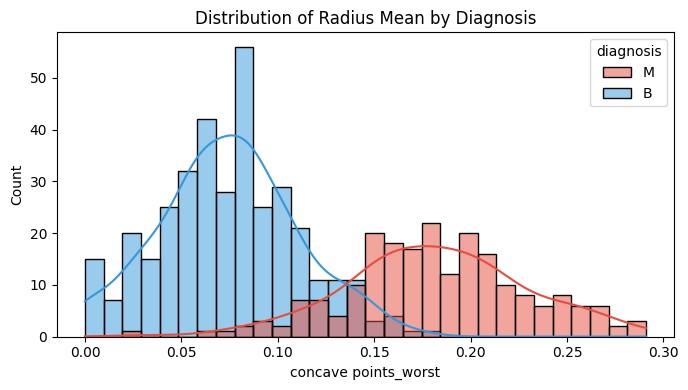

In [ ]:
pt.figure(figsize=(7, 4))
sns.histplot(data=input_df, x='concave points_worst', hue='diagnosis',
             palette={'M': '#e74c3c', 'B': '#3498db'},
             kde=True,          # adds a smooth curve over the histogram
             bins=30)
pt.title('Distribution of Radius Mean by Diagnosis')
pt.tight_layout()
pt.show()

In [ ]:
# Good for spotting whether two features together separate M from B cleanly
px.scatter(input_df,
           x='radius_mean', y='texture_mean',
           color='diagnosis',
           color_discrete_map={'M': '#e74c3c', 'B': '#3498db'},
           title='Radius Mean vs Texture Mean by Diagnosis',
           opacity=0.7)

In [ ]:

# Good for spotting whether two features together separate M from B cleanly
px.scatter(input_df,
           x='concave points_worst', y='perimeter_worst',
           color='diagnosis',
           color_discrete_map={'M': '#e74c3c', 'B': '#3498db'},
           title='Radius Mean vs Texture Mean by Diagnosis',
           opacity=0.7)

In [10]:
# Create a true independent copy so the original DataFrame is never modified
input_df_copy = input_df.copy()

# Explicitly define input and target columns by name — not by position
# This is safer and more readable than slicing with [1:-1]
input_cols = input_df_copy.drop(columns=['diagnosis', 'diagnosis_code']).columns.tolist()
target_col = 'diagnosis_code'

print(f"Number of input features : {len(input_cols)}")
print(f"Input columns : {input_cols}")
print()
print(f"Target column : {target_col}")

# Split into train (70%) and test (30%) sets
# random_state=42 ensures the same split every time I run this cell
train_df, test_df = train_test_split(input_df_copy, test_size=0.3, random_state=42)

print()
print(f"Training set : {train_df.shape[0]} rows")
print(f"Test set     : {test_df.shape[0]} rows")

Number of input features : 30
Input columns : ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Target column : diagnosis_code

Training set : 398 rows
Test set     : 171 rows


In [11]:
# Full training DataFrame — rendered as a formatted table
train_df
# Input features only
train_df[input_cols]
# Target column only
train_df[target_col]



,diagnosis_code
149,0
124,0
421,0
195,0
545,0
...,...
71,0
106,0
270,0
435,1


In [12]:
# Full training DataFrame — rendered as a formatted table
test_df
# Input features only
test_df[input_cols]
# Target column only
test_df[target_col]



,diagnosis_code
204,0
70,1
131,1
431,0
540,0
...,...
69,0
542,0
176,0
501,1


In [29]:
# Fit the scaler on training data only — never on test data
scalar = MinMaxScaler()
scalar.fit(train_df[input_cols])

# Apply scaling to both splits
train_input_scaled = pd.DataFrame(
    scalar.transform(train_df[input_cols]),
    columns=input_cols,
    index=train_df.index)

test_input_scaled = pd.DataFrame(
    scalar.transform(test_df[input_cols]),
    columns=input_cols,
    index=test_df.index)

In [30]:
model = LogisticRegression(solver='liblinear')
model.fit(train_input_scaled, train_df[target_col])

print("Model training complete.")

Model training complete.


In [31]:
train_prediction = model.predict(train_input_scaled)
train_prob = model.predict_proba(train_input_scaled)
print("Target classes:", model.classes_)

Target classes: [0 1]


In [32]:
from sklearn.metrics import accuracy_score
train_accuracy = accuracy_score(train_df[target_col],train_prediction)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

Training Accuracy: 95.98%


Accuracy: 96.49%


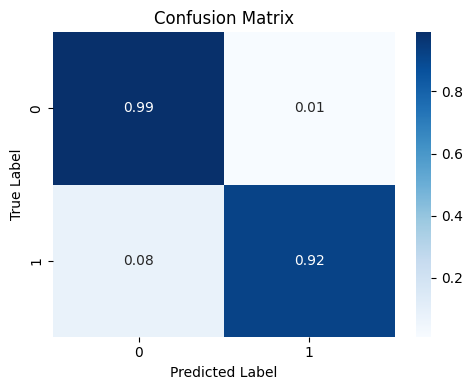

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix
def evaluate_result(input,target):
  prediction = model.predict(input)
  accuracy = accuracy_score(target,prediction)
  cf = confusion_matrix(target, prediction, normalize='true')
  print(f"Accuracy: {accuracy * 100:.2f}%")

  pt.figure(figsize=(5, 4))
  sns.heatmap(cf, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
  pt.xlabel('Predicted Label')
  pt.ylabel('True Label')
  pt.title(f'Confusion Matrix')
  pt.tight_layout()
  pt.show()

  return prediction

test_predition = evaluate_result(test_input_scaled,test_df[target_col])

In [35]:
import joblib

# Bundle the model with the scaler — both are needed to make predictions.
# new inputs must be scaled the same way before prediction.
breast_cancer_bundle = {
    'model':        model,
    'scaler':       scalar,
    'input_cols':   input_cols,
    'target_col':   target_col
}

joblib.dump(breast_cancer_bundle, 'breast_cancer_model.joblib')
print("Model saved to: breast_cancer_model.joblib")

Model saved to: breast_cancer_model.joblib


In [36]:
loaded = joblib.load('breast_cancer_model.joblib')

test_input_reloaded = pd.DataFrame(
    loaded['scaler'].transform(test_df[loaded['input_cols']]),
    columns=loaded['input_cols'],
    index=test_df.index
)

reloaded_accuracy = accuracy_score(
    test_df[target_col],
    loaded['model'].predict(test_input_reloaded)
)
print(f"Reloaded model accuracy: {reloaded_accuracy * 100:.2f}%")
print("✅ No warnings — model and scaler are consistent.")

Reloaded model accuracy: 96.49%
✅ No warnings — model and scaler are consistent.


In [38]:
from google.colab import files
files.download('breast_cancer_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>